### Mini Project 2
#### Team Members: Ledja Halltari & Sepehr Mansouri

In [8]:
%pip install imbalanced-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Setup

np.random.seed(42) # Random seed for reproducibility
plt.style.use('default')
sns.set_palette("husl")

model_results = []


Note: you may need to restart the kernel to use updated packages.


In [9]:
DATA_PATH = "../data/diabetes.csv"
df = pd.read_csv(DATA_PATH)
print("data shape:", df.shape)
df.head()

data shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1) Data Preprocessing

In [10]:
display(df.head())

# Dataset info
print("\n📋 Dataset Information:")
print(df.info())

# Checking missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values! ✓")

# Target Variable Distribution
print("\n Class Distribution:")
class_dist = df['Outcome'].value_counts()
print(class_dist)
print("\n Class Balance:")
class_pct = df['Outcome'].value_counts(normalize=True) * 100
print(class_pct)

X = df.drop('Outcome', axis=1)
y = df['Outcome']


# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
No missing values! ✓

 Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

 Class Balance:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## 2) Model Training

### i) Logistic Regression

In [21]:

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Generating Prediction
y_pred_log_reg = log_reg.predict(X_test_scaled)
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)

log_reg_report = classification_report(y_test, y_pred_log_reg, target_names=['Legitimate', 'Fraud'])

print("Logistic Regression training complete")
model_results.append({"model": "LogisticRegression", "accuracy": log_reg_accuracy, "report": log_reg_report})

print(model_results[0]["report"])


Logistic Regression training complete
              precision    recall  f1-score   support

  Legitimate       0.76      0.82      0.79       100
       Fraud       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



### ii) Random Forest

In [22]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train) # Fitting Model
 
# Generating Prediction
y_pred_rf = rf.predict(X_test_scaled)

# Metrics calculations
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_score = f1_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud'])


print("Random Forest training complete")
model_results.append({"model": "RandomForest", "accuracy": rf_accuracy, "f1_score": rf_f1_score, "report": rf_report})


Random Forest training complete


### iii) Model To be decided

In [ ]:
# Code to be added by Ledja

## 3) Hyperparameter Tuning

In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print(param_grid)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_parameters = grid_search.best_params_
print("Best Parameters from Grid Search:", best_parameters)

best_f1_score = grid_search.best_score_
print("Best F1 Score from Grid Search:", best_f1_score)


{'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters from Grid Search: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best F1 Score from Grid Search: 0.6342129858705811


## 4) Imbalanced Data Handling

### Confusion Matrix

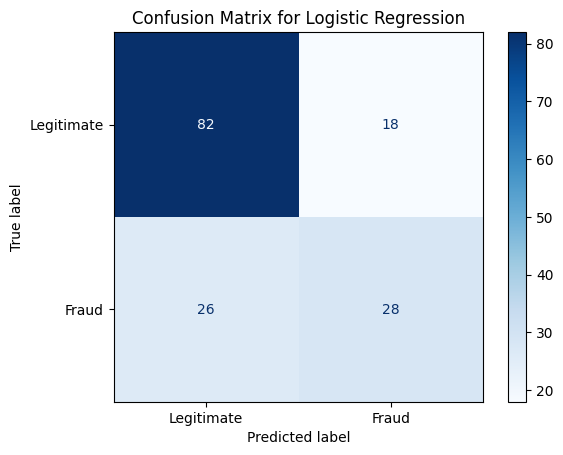

True Negatives (TN):  82 - Identified Diabetes correctly
False Positives (FP): 18 - Falely flagged as Diabetes
False Negatives (FN): 26 - Missed actual Diabetes cases
True Positives (TP):  28 - Correctly identified Diabetes cases


Diabetes Detection Performance:
Precision: 0.6087 - Out of all predictions we classified as fraud, 60.87% were actually fraud cases (measures false positive rate)
Recall:    0.5185 - Out of all actual fraud cases in the dataset, we successfully identified 51.85% of them (measures false negative rate)
F1 Score:  0.5600 - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better


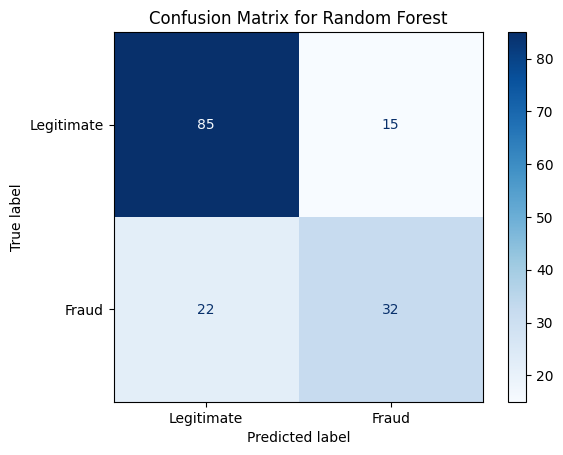

True Negatives (TN):  85 - Identified Diabetes correctly
False Positives (FP): 15 - Falely flagged as Diabetes
False Negatives (FN): 22 - Missed actual Diabetes cases
True Positives (TP):  32 - Correctly identified Diabetes cases


Diabetes Detection Performance:
Precision: 0.6809 - Out of all predictions we classified as fraud, 68.09% were actually fraud cases (measures false positive rate)
Recall:    0.5926 - Out of all actual fraud cases in the dataset, we successfully identified 59.26% of them (measures false negative rate)
F1 Score:  0.6337 - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better


In [29]:
# do confusion matrix & visualization for all models. Maybe create a method where I can only pass in the model info and it will handle and plot the confusion matrix
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
    confusion_matrix_display.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()
    fraud_precision = precision_score(y_test, y_pred, average='binary')
    fraud_recall = recall_score(y_test, y_pred, average='binary')
    fraud_f1 = f1_score(y_test, y_pred, average='binary')

    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (TN):  {tn:,} - Identified Diabetes correctly")
    print(f"False Positives (FP): {fp:,} - Falely flagged as Diabetes")
    print(f"False Negatives (FN): {fn:,} - Missed actual Diabetes cases")
    print(f"True Positives (TP):  {tp:,} - Correctly identified Diabetes cases")

    print("\n")
    print("Diabetes Detection Performance:")
    print(f"Precision: {fraud_precision:.4f} - Out of all predictions we classified as fraud, {fraud_precision*100:.2f}% were actually fraud cases (measures false positive rate)")
    print(f"Recall:    {fraud_recall:.4f} - Out of all actual fraud cases in the dataset, we successfully identified {fraud_recall*100:.2f}% of them (measures false negative rate)")
    print(f"F1 Score:  {fraud_f1:.4f} - Balanced overall metric that combines precision and recall; ranges from 0 to 1 where higher is better")



# Logistic Regression Confusion Matrix
plot_confusion_matrix(y_test, y_pred_log_reg, "Logistic Regression")

# Random Forest Confusion Matrix
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")


# TODO: You can simply add the third model here like the above
# plot_confusion_matrix(y_test, ......, "[SOME NAME]") 



### ROC & AUC

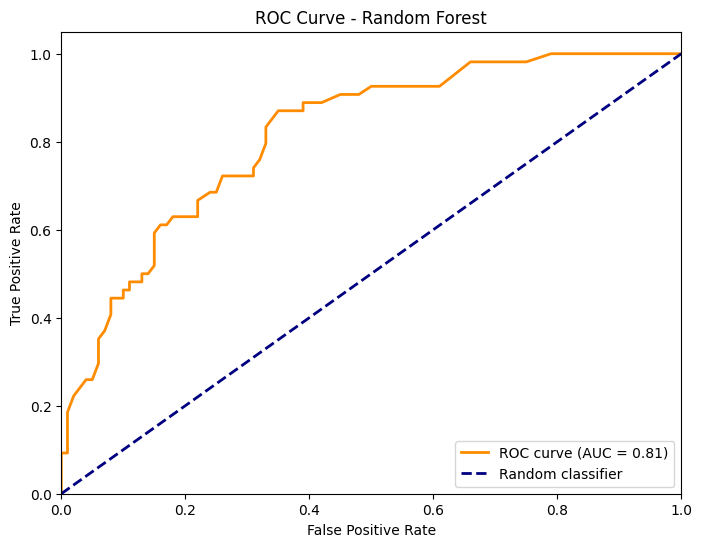

In [30]:
# Getting Probablility prediction from positive class
y_pred_probabability = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probabability)

# Calculating ROC & AUC
roc_auc = roc_auc_score(y_test, y_pred_probabability)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

## 5) Model Evaluation

In [26]:
for result in model_results:
    print(f"Model: {result['model']}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    if 'f1_score' in result:
        print(f"F1 Score: {result['f1_score']:.4f}")
    print("Classification Report:")
    print(result['report'])
    print("=" * 50)
    print("\n")

Model: LogisticRegression
Accuracy: 0.7143
Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.76      0.82      0.79       100
       Fraud       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



Model: LogisticRegression
Accuracy: 0.7143
Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.76      0.82      0.79       100
       Fraud       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



Model: LogisticRegression
Accuracy: 0.7143
Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.76      0.82      0.79       100
       Fraud       0.61      0.52  

## 6) Analysis